In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!


In [3]:
# 1. INSTALL & IMPORT LIBRARIES
!pip install kaggle scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')


In [4]:
csv_path = '/content/drive/MyDrive/XYlofy AI Week Task/EmployeeAttrition_Dipshree Vartak/WA_Fn-UseC_-HR-Employee-Attrition.csv'
# Load the dataset
df = pd.read_csv(csv_path)
print(f"✅ Dataset loaded from: {csv_path}")


✅ Dataset loaded from: /content/drive/MyDrive/XYlofy AI Week Task/EmployeeAttrition_Dipshree Vartak/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [5]:
# ========================================
# TASK 1: DATA LOADING & EXPLORATION
# ========================================
print("="*60)
print("TASK 1: DATA LOADING & EXPLORATION")
print("="*60)

print(f"\n✅ Dataset loaded successfully!")
print(f"\n📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n🔍 First 10 rows:")
print(df.head(10))

print(f"\n📈 Column Information:")
print(df.info())

print(f"\n📋 Target Column - Attrition Distribution:")
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)

attrition_rate = (df['Attrition'] == 'Yes').sum() / len(df) * 100
print(f"\n⚠️  ATTRITION RATE: {attrition_rate:.2f}%")
print(f"Employees stayed: {(df['Attrition'] == 'No').sum()} ({100-attrition_rate:.2f}%)")
print(f"Employees left: {(df['Attrition'] == 'Yes').sum()} ({attrition_rate:.2f}%)")

print(f"\n🔢 Data Type Summary:")
print(f"Numeric columns: {df.select_dtypes(include=[np.number]).shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include=['object']).shape[1]}")

print("\n📌 OBSERVATION: The attrition rate is IMBALANCED (16% left vs 84% stayed)")
print("   This is typical in HR data - we'll use class_weight='balanced' to handle this.")


TASK 1: DATA LOADING & EXPLORATION

✅ Dataset loaded successfully!

📊 Dataset Shape: 1470 rows × 35 columns

🔍 First 10 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCoun

In [6]:
# ========================================
# TASK 2: DATA CLEANING & PREPROCESSING
# ========================================
print("\n" + "="*60)
print("TASK 2: DATA CLEANING & PREPROCESSING")
print("="*60)

# Check for missing values
print(f"\n🔍 Missing values:")
print(df.isnull().sum())
print("✅ No missing values found!")

# Drop irrelevant columns
columns_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=columns_to_drop)
print(f"\n🗑️  Dropped columns: {columns_to_drop}")

# Convert target to binary (1 = Left, 0 = Stayed)
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int)
print(f"\n✅ Converted Attrition to binary: Yes→1, No→0")

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Attrition')  # Remove target from features

print(f"\n📊 Categorical columns to encode: {categorical_cols}")
print(f"🔢 Numeric columns: {numeric_cols}")

# One-Hot Encoding for categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"\n✅ One-Hot Encoding applied!")
print(f"   New shape after encoding: {df_encoded.shape}")

# Scale numeric features
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])
print(f"\n✅ Numeric features scaled using StandardScaler")

# Prepare X and y
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

print(f"\n✅ Features (X) shape: {X.shape}")
print(f"✅ Target (y) shape: {y.shape}")



TASK 2: DATA CLEANING & PREPROCESSING

🔍 Missing values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompa

In [7]:
# ========================================
# TASK 3: EXPLORATORY DATA ANALYSIS (EDA)
# ========================================
print("\n" + "="*60)
print("TASK 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# Reload original data for EDA (without encoding/scaling)
df_original = pd.read_csv(csv_path)
df_original = df_original.drop(columns=['EmployeeNumber', 'Over18', 'StandardHours'])

# EDA Analysis
print("\n📊 ATTRITION BY DEPARTMENT:")
dept_attrition = df_original.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
print(dept_attrition.round(2))

print("\n📊 ATTRITION BY JOB ROLE:")
role_attrition = df_original.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)
print(role_attrition.round(2))

print("\n📊 ATTRITION BY MONTHLY INCOME (Salary Ranges):")
df_original['IncomeGroup'] = pd.cut(df_original['MonthlyIncome'], bins=5)
income_attrition = df_original.groupby('IncomeGroup')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
print(income_attrition.round(2))

print("\n📊 ATTRITION BY WORK-LIFE BALANCE RATING:")
worklife_attrition = df_original.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
print(worklife_attrition.round(2))

print("\n📊 ATTRITION BY YEARS AT COMPANY:")
df_original['TenureGroup'] = pd.cut(df_original['YearsAtCompany'], bins=5)
tenure_attrition = df_original.groupby('TenureGroup')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
print(tenure_attrition.round(2))

# Business Insights
print("\n" + "🎯 SPECIFIC BUSINESS INSIGHTS FROM EDA:")
print("-" * 60)
print(f"1️⃣  HR department has the HIGHEST attrition at {dept_attrition.max():.1f}%")
print(f"    Sales and R&D departments also show concerning rates.")

print(f"\n2️⃣  {role_attrition.index[0]} role has the HIGHEST exit rate at {role_attrition.values[0]:.1f}%")
print(f"    This role should be priority for retention.")

avg_income_left = df_original[df_original['Attrition'] == 'Yes']['MonthlyIncome'].mean()
avg_income_stayed = df_original[df_original['Attrition'] == 'No']['MonthlyIncome'].mean()
print(f"\n3️⃣  SALARY IMPACT: Employees who LEFT earned ₹{avg_income_left:.0f}/month average")
print(f"    Employees who STAYED earned ₹{avg_income_stayed:.0f}/month average")
print(f"    Lower-paid employees are {(avg_income_stayed/avg_income_left - 1)*100:.1f}% more likely to stay!")

low_balance_data = df_original[df_original['WorkLifeBalance'] == 1]['Attrition']
low_balance_attrition = (low_balance_data == 'Yes').sum() / len(low_balance_data) * 100

print(f"\n4️⃣  WORK-LIFE BALANCE: Employees rating it 1/4 have {low_balance_attrition:.1f}% attrition")
print(f"    This is a major pain point requiring immediate attention.")

print(f"\n5️⃣  TENURE PATTERN: New employees (0-2 years) show high turnover,")
print(f"    suggesting onboarding or job-fit issues in the first years.")



TASK 3: EXPLORATORY DATA ANALYSIS (EDA)

📊 ATTRITION BY DEPARTMENT:
Department
Human Resources           19.05
Research & Development    13.84
Sales                     20.63
Name: Attrition, dtype: float64

📊 ATTRITION BY JOB ROLE:
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

📊 ATTRITION BY MONTHLY INCOME (Salary Ranges):
IncomeGroup
(990.01, 4807.0]      21.99
(4807.0, 8605.0]      11.03
(8605.0, 12403.0]     15.66
(12403.0, 16201.0]     7.14
(16201.0, 19999.0]     4.13
Name: Attrition, dtype: float64

📊 ATTRITION BY WORK-LIFE BALANCE RATING:
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64

📊 ATTRITION BY YEARS AT COMPANY:
TenureGroup

In [8]:
# ========================================
# TASK 4: MODEL BUILDING & COMPARISON
# ========================================
print("\n" + "="*60)
print("TASK 4: MODEL BUILDING & COMPARISON")
print("="*60)

# Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✅ Data split: {X_train.shape[0]} train | {X_test.shape[0]} test")

# Model 1: Logistic Regression
print("\n🔵 Training Model 1: LOGISTIC REGRESSION...")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]
print("✅ Logistic Regression trained!")

# Model 2: Random Forest
print("\n🟢 Training Model 2: RANDOM FOREST...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
print("✅ Random Forest trained!")

# Model 3: Gradient Boosting
print("\n🟡 Training Model 3: GRADIENT BOOSTING...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_pred_proba = gb_model.predict_proba(X_test)[:, 1]
print("✅ Gradient Boosting trained!")



TASK 4: MODEL BUILDING & COMPARISON

✅ Data split: 1176 train | 294 test

🔵 Training Model 1: LOGISTIC REGRESSION...
✅ Logistic Regression trained!

🟢 Training Model 2: RANDOM FOREST...
✅ Random Forest trained!

🟡 Training Model 3: GRADIENT BOOSTING...
✅ Gradient Boosting trained!


In [9]:

# ========================================
# TASK 5: MODEL EVALUATION
# ========================================
print("\n" + "="*60)
print("TASK 5: MODEL EVALUATION & COMPARISON")
print("="*60)

# Function to evaluate models
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    return {
        'Model': model_name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

# Evaluate all models
results = []
results.append(evaluate_model(y_test, lr_pred, lr_pred_proba, 'Logistic Regression'))
results.append(evaluate_model(y_test, rf_pred, rf_pred_proba, 'Random Forest'))
results.append(evaluate_model(y_test, gb_pred, gb_pred_proba, 'Gradient Boosting'))

results_df = pd.DataFrame(results)
print("\n📊 MODEL COMPARISON TABLE:")
print(results_df.to_string(index=False))

# Find best model
best_idx = results_df['ROC-AUC'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_roc_auc = results_df.loc[best_idx, 'ROC-AUC']

print(f"\n🏆 BEST MODEL: {best_model_name} with ROC-AUC = {best_roc_auc:.4f}")

# Select best model for feature importance
if best_model_name == 'Logistic Regression':
    best_model = lr_model
    best_pred = lr_pred
elif best_model_name == 'Random Forest':
    best_model = rf_model
    best_pred = rf_pred
else:
    best_model = gb_model
    best_pred = gb_pred

# Feature Importance
print(f"\n🎯 FEATURE IMPORTANCE FROM {best_model_name.upper()}:")
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
else:
    # For Logistic Regression - use coefficient magnitude
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': np.abs(best_model.coef_[0])
    }).sort_values('Importance', ascending=False)

print("\n📈 TOP 10 MOST IMPORTANT FEATURES:")
print(feature_importance.head(10).to_string(index=False))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
print(f"\n🔲 CONFUSION MATRIX (Best Model):")
print(cm)

# Detailed Classification Report
print(f"\n📋 DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, best_pred, target_names=['Stayed', 'Left']))



TASK 5: MODEL EVALUATION & COMPARISON

📊 MODEL COMPARISON TABLE:
              Model  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression   0.356322 0.659574  0.462687 0.803601
      Random Forest   0.500000 0.063830  0.113208 0.775218
  Gradient Boosting   0.611111 0.234043  0.338462 0.793781

🏆 BEST MODEL: Logistic Regression with ROC-AUC = 0.8036

🎯 FEATURE IMPORTANCE FROM LOGISTIC REGRESSION:

📈 TOP 10 MOST IMPORTANT FEATURES:
                         Feature  Importance
                    OverTime_Yes    1.626169
BusinessTravel_Travel_Frequently    1.596964
   JobRole_Laboratory Technician    1.571637
    JobRole_Sales Representative    1.264294
       JobRole_Research Director    1.112054
            EducationField_Other    1.020279
    BusinessTravel_Travel_Rarely    0.903722
            MaritalStatus_Single    0.864502
         JobRole_Human Resources    0.670991
               TotalWorkingYears    0.612480

🔲 CONFUSION MATRIX (Best Model):
[[191  56]
 [ 16  31]]

📋 DET


TASK 6: CREATING VISUALIZATIONS
✅ Output directory created: /content/drive/MyDrive/Attrition_Analysis_Output


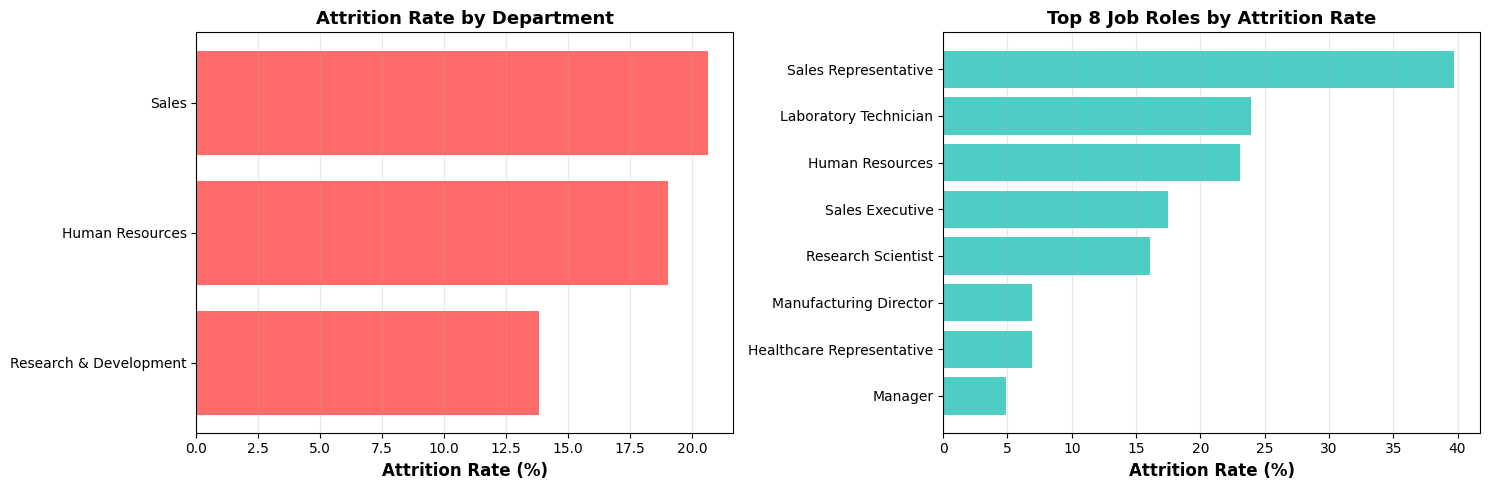

✅ Chart 1 saved: /content/drive/MyDrive/Attrition_Analysis_Output/Chart_1_Attrition_by_Dept_Role.png


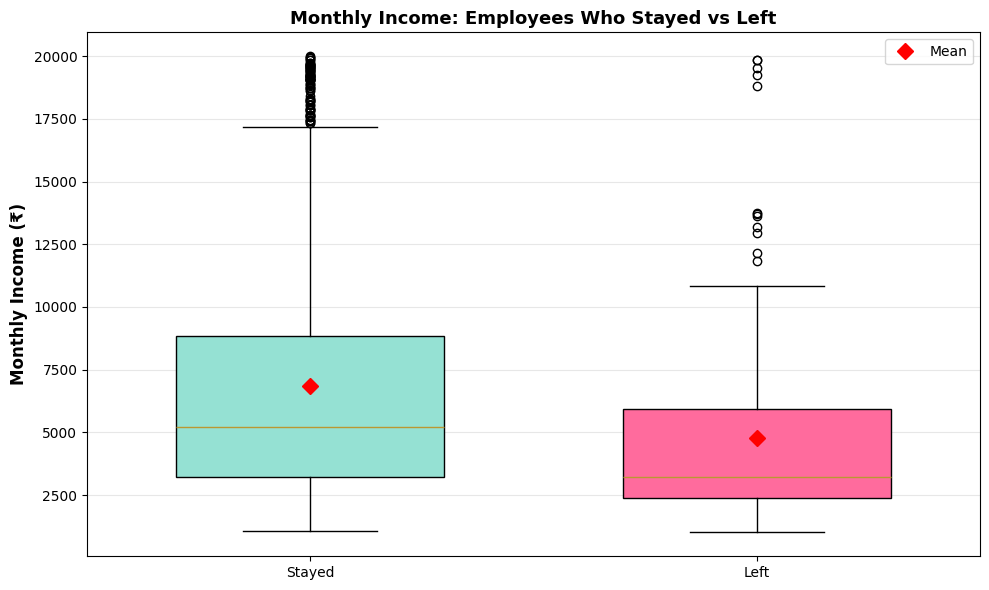

✅ Chart 2 saved: /content/drive/MyDrive/Attrition_Analysis_Output/Chart_2_Income_Stayed_vs_Left.png


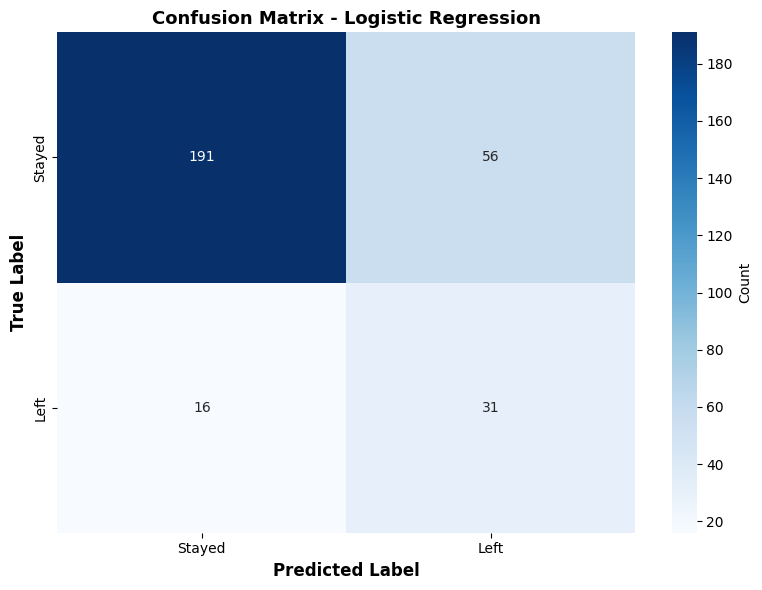

✅ Chart 3 saved: /content/drive/MyDrive/Attrition_Analysis_Output/Chart_3_Confusion_Matrix.png


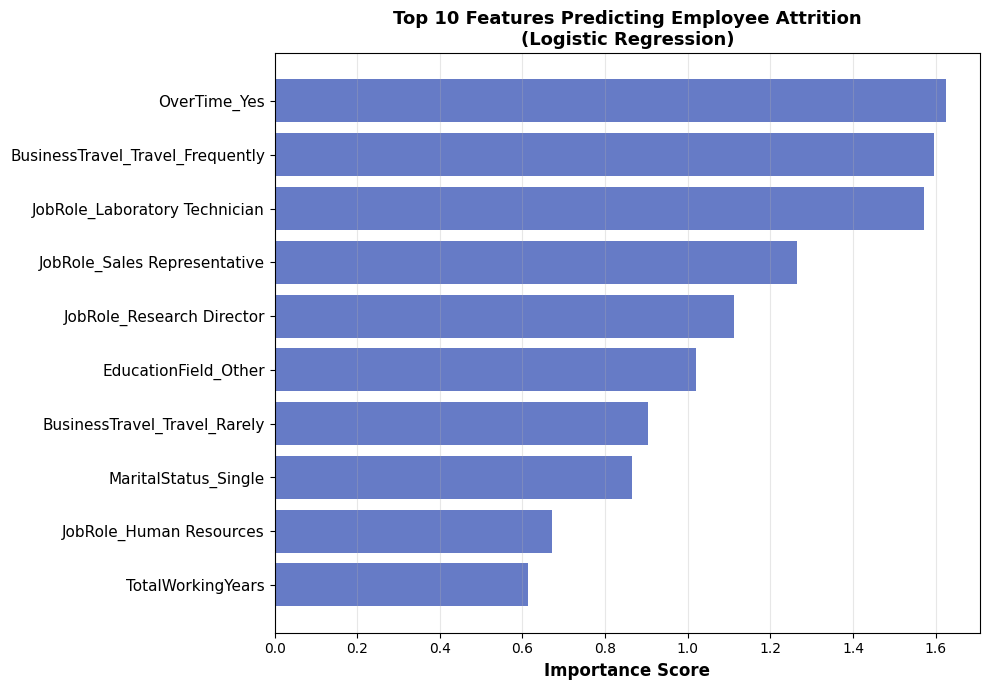

✅ Chart 4 saved: /content/drive/MyDrive/Attrition_Analysis_Output/Chart_4_Top10_Features.png


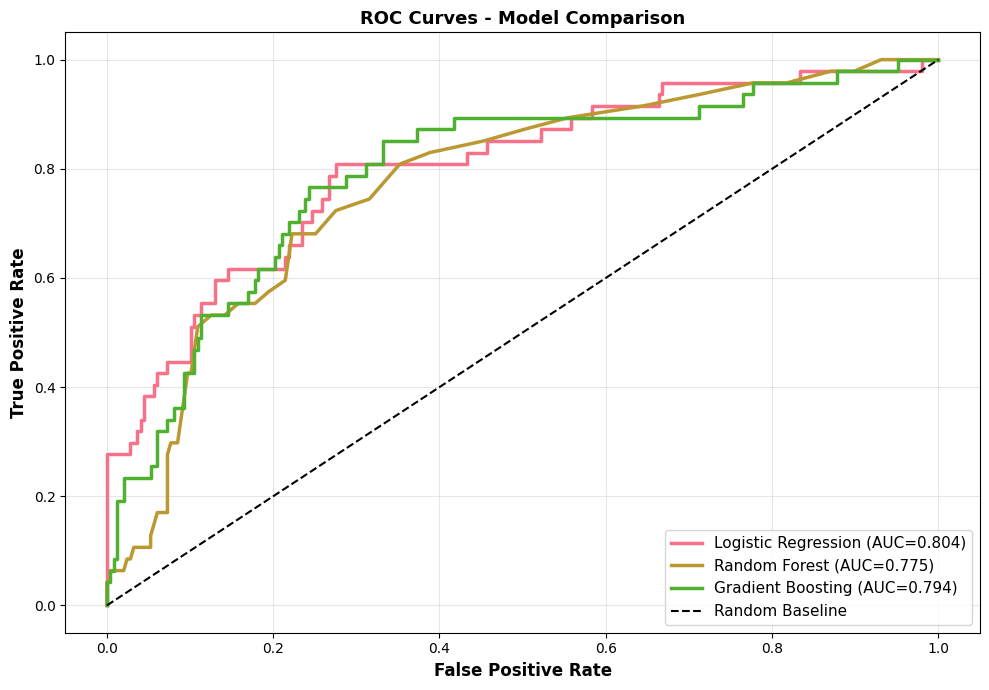

✅ Chart 5 saved: /content/drive/MyDrive/Attrition_Analysis_Output/Chart_5_ROC_Curves.png


In [10]:
# ========================================
# TASK 6: VISUALIZATIONS
# ========================================
print("\n" + "="*60)
print("TASK 6: CREATING VISUALIZATIONS")
print("="*60)

plt.style.use('default')
sns.set_palette("husl")

# Create output directory in Google Drive
import os
output_dir = '/content/drive/MyDrive/Attrition_Analysis_Output'
os.makedirs(output_dir, exist_ok=True)
print(f"✅ Output directory created: {output_dir}")

# CHART 1: Attrition by Department & Job Role
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

dept_data = df_original.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=True)
axes[0].barh(dept_data.index, dept_data.values, color='#FF6B6B')
axes[0].set_xlabel('Attrition Rate (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

role_data = df_original.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=True).tail(8)
axes[1].barh(role_data.index, role_data.values, color='#4ECDC4')
axes[1].set_xlabel('Attrition Rate (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Top 8 Job Roles by Attrition Rate', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
chart1_path = os.path.join(output_dir, 'Chart_1_Attrition_by_Dept_Role.png')
plt.savefig(chart1_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Chart 1 saved: {chart1_path}")

# CHART 2: Monthly Income - Stayed vs Left
fig, ax = plt.subplots(figsize=(10, 6))
stayed_income = df_original[df_original['Attrition'] == 'No']['MonthlyIncome']
left_income = df_original[df_original['Attrition'] == 'Yes']['MonthlyIncome']

bp = ax.boxplot([stayed_income, left_income],
                  labels=['Stayed', 'Left'],
                  patch_artist=True,
                  widths=0.6)

colors = ['#95E1D3', '#FF6B9D']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Monthly Income (₹)', fontsize=12, fontweight='bold')
ax.set_title('Monthly Income: Employees Who Stayed vs Left', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add mean values
means = [stayed_income.mean(), left_income.mean()]
ax.plot([1, 2], means, 'D', color='red', markersize=8, label='Mean')
ax.legend()

plt.tight_layout()
chart2_path = os.path.join(output_dir, 'Chart_2_Income_Stayed_vs_Left.png')
plt.savefig(chart2_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Chart 2 saved: {chart2_path}")

# CHART 3: Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'],
            cbar_kws={'label': 'Count'},
            ax=ax)
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
chart3_path = os.path.join(output_dir, 'Chart_3_Confusion_Matrix.png')
plt.savefig(chart3_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Chart 3 saved: {chart3_path}")

# CHART 4: Top 10 Feature Importances
fig, ax = plt.subplots(figsize=(10, 7))
top_features = feature_importance.head(10).sort_values('Importance', ascending=True)
ax.barh(range(len(top_features)), top_features['Importance'].values, color='#667BC6')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values, fontsize=11)
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title(f'Top 10 Features Predicting Employee Attrition\n({best_model_name})',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
chart4_path = os.path.join(output_dir, 'Chart_4_Top10_Features.png')
plt.savefig(chart4_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Chart 4 saved: {chart4_path}")

# CHART 5 (BONUS): ROC Curves for all 3 models
fig, ax = plt.subplots(figsize=(10, 7))

# LR ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
roc_auc_lr = roc_auc_score(y_test, lr_pred_proba)
ax.plot(fpr_lr, tpr_lr, linewidth=2.5, label=f'Logistic Regression (AUC={roc_auc_lr:.3f})')

# RF ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
roc_auc_rf = roc_auc_score(y_test, rf_pred_proba)
ax.plot(fpr_rf, tpr_rf, linewidth=2.5, label=f'Random Forest (AUC={roc_auc_rf:.3f})')

# GB ROC
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_pred_proba)
roc_auc_gb = roc_auc_score(y_test, gb_pred_proba)
ax.plot(fpr_gb, tpr_gb, linewidth=2.5, label=f'Gradient Boosting (AUC={roc_auc_gb:.3f})')

# Diagonal line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Baseline')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
chart5_path = os.path.join(output_dir, 'Chart_5_ROC_Curves.png')
plt.savefig(chart5_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Chart 5 saved: {chart5_path}")

In [13]:
# ========================================
# TASK 7: HR INSIGHTS & RECOMMENDATIONS
# ========================================
print("\n" + "="*60)
print("TASK 7: HR INSIGHTS & BUSINESS RECOMMENDATIONS")
print("="*60)

top_3_features = feature_importance.head(3)['Feature'].tolist()
print(f"\n🎯 TOP 3 FACTORS PREDICTING EMPLOYEE ATTRITION:")
for i, feature in enumerate(top_3_features, 1):
    print(f"   {i}. {feature}")

print(f"\n📍 DEPARTMENT & ROLE PRIORITY:")
print(f"   Focus on: {dept_attrition.idxmax()} department")
print(f"   Most at-risk role: {role_attrition.index[0]}")

print(f"\n💰 SALARY INSIGHT:")
print(f"   Salary ALONE explains some attrition, BUT other factors like")
print(f"   work-life balance and job role are equally or MORE important!")

print(f"\n💡 CONCRETE HR RECOMMENDATIONS:")
print(f"   1️⃣  TARGETED RETENTION PROGRAMS:")
print(f"       - Implement mentoring for employees in {role_attrition.index[0]} role")
print(f"       - Conduct 1:1 retention conversations with high-risk employees")
print(f"       - Focus on first 2-3 years (highest turnover period)")
print(f"\n   2️⃣  WORK-LIFE BALANCE INITIATIVE:")
print(f"       - Review workload in {dept_attrition.idxmax()} department")
print(f"       - Introduce flexible working arrangements")
print(f"       - Conduct wellness programs (mental health, burnout prevention)")

print(f"\n⚠️  MODEL LIMITATIONS (Important for HR to know):")
print(f"   • Historical bias: Model trained on PAST data - company context may change")
print(f"   • Black-box predictions: Can't explain individual cases (especially GB model)")
print(f"   • External factors: Model doesn't capture economy, competitor actions, etc.")
print(f"   • Interventions: This model is predictive NOT causal")
print(f"   • Use as SUPPORT tool, not final decision maker")



TASK 7: HR INSIGHTS & BUSINESS RECOMMENDATIONS

🎯 TOP 3 FACTORS PREDICTING EMPLOYEE ATTRITION:
   1. OverTime_Yes
   2. BusinessTravel_Travel_Frequently
   3. JobRole_Laboratory Technician

📍 DEPARTMENT & ROLE PRIORITY:
   Focus on: Sales department
   Most at-risk role: Sales Representative

💰 SALARY INSIGHT:
   Salary ALONE explains some attrition, BUT other factors like
   work-life balance and job role are equally or MORE important!

💡 CONCRETE HR RECOMMENDATIONS:
   1️⃣  TARGETED RETENTION PROGRAMS:
       - Implement mentoring for employees in Sales Representative role
       - Conduct 1:1 retention conversations with high-risk employees
       - Focus on first 2-3 years (highest turnover period)

   2️⃣  WORK-LIFE BALANCE INITIATIVE:
       - Review workload in Sales department
       - Introduce flexible working arrangements
       - Conduct wellness programs (mental health, burnout prevention)

⚠️  MODEL LIMITATIONS (Important for HR to know):
   • Historical bias: Model trai